In [3]:
%pip install numpy matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

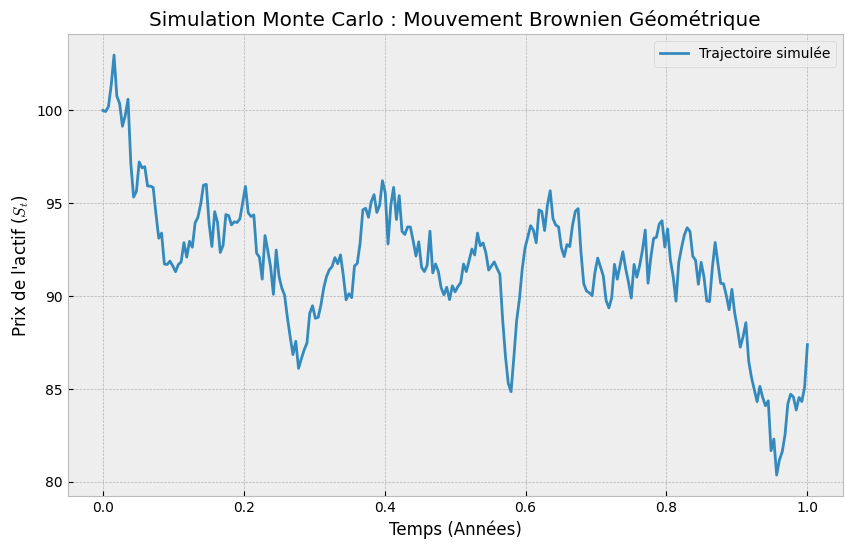

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Paramètres du Marché ---
S0 = 100       # Prix initial de l'action
T = 1.0        # Durée (1 an)
r = 0.05       # Taux d'intérêt (5%)
sigma = 0.2    # Volatilité (20% de remous)
n_steps = 252  # Jours de trading dans un an

# --- 2. Préparation du Temps ---
dt = T / n_steps                # Durée d'un pas de temps (1 jour)
t = np.linspace(0, T, n_steps + 1) # Axe temporel (0, 1/252, 2/252... 1)

# --- 3. Le Moteur (La boucle) ---
# On crée un tableau vide pour stocker les prix
S = np.zeros(n_steps + 1)
S[0] = S0

# On avance jour après jour
for i in range(1, n_steps + 1):
    # Z : Le tirage aléatoire (Loi Normale centrée réduite)
    Z = np.random.normal(0, 1) 
    
    # La formule du cours (GBM)
    drift = (r - 0.5 * sigma**2) * dt
    shock = sigma * np.sqrt(dt) * Z
    
    # Prix jour suivant = Prix jour actuel * variation
    S[i] = S[i-1] * np.exp(drift + shock)

# --- 4. Visualisation ---
plt.figure(figsize=(10, 6))
plt.plot(t, S, label='Trajectoire simulée')
plt.title(f"Simulation Monte Carlo : Mouvement Brownien Géométrique")
plt.xlabel("Temps (Années)")
plt.ylabel("Prix de l'actif ($S_t$)")
plt.legend()
plt.grid(True)
plt.show()

In [5]:


# Style "Pro" pour les graphiques
plt.style.use('bmh')

def run_counterparty_risk_engine(S0=100, K=100, T=1.0, r=0.05, sigma=0.2, n_simulations=1000):
    """
    Moteur complet de calcul de risque de contrepartie (PFE/EPE) 
    pour un contrat Forward.
    """
    
    # --- PARTIE 1 : Configuration de la Simulation ---
    n_steps = 252  # Un an de jours de trading
    dt = T / n_steps
    time_grid = np.linspace(0, T, n_steps + 1)
    
    # --- PARTIE 2 : Moteur Monte Carlo (Génération des prix S_t) ---
    # S_t = S_0 * exp((r - 0.5*sigma^2)t + sigma*W_t)
    
    # Génération des chocs aléatoires (Matrice: Simulations x Pas de temps)
    Z = np.random.standard_normal((n_simulations, n_steps))
    
    # Construction du Mouvement Brownien cumulé (W_t)
    W = np.zeros((n_simulations, n_steps + 1))
    W[:, 1:] = np.cumsum(Z * np.sqrt(dt), axis=1)
    
    # Calcul vectorisé des trajectoires de prix
    drift_term = (r - 0.5 * sigma**2) * time_grid
    diffusion_term = sigma * W
    S_t = S0 * np.exp(drift_term + diffusion_term)
    
    # --- PARTIE 3 : Moteur de Valuation (Mark-to-Market) ---
    # Produit : Forward (Achat de l'actif à K dans le futur)
    # Valeur V_t = S_t - K * e^(-r(T-t))
    # Note : Si le prix monte, on gagne (V > 0). Si ça baisse, on perd (V < 0).
    
    PV_K = K * np.exp(-r * (T - time_grid)) # Actualisation du strike
    V_t = S_t - PV_K
    
    # --- PARTIE 4 : Moteur de Risque (Exposition) ---
    # Règle d'or : L'exposition est le max(V_t, 0).
    # Si la valeur est négative (on doit de l'argent à la banque), 
    # le risque de contrepartie est NUL (c'est eux qui ont un risque sur nous).
    
    E_t = np.maximum(V_t, 0)
    
    # --- PARTIE 5 : Agrégation (EPE & PFE) ---
    
    # EPE (Expected Positive Exposure) : La "Moyenne" du risque
    # Utilisé pour le calcul de la CVA (Pricing)
    EPE = np.mean(E_t, axis=0)
    
    # PFE (Potential Future Exposure) : Le "Pire Cas" (Quantile 99%)
    # Utilisé pour les limites de crédit et le capital (Bâle)
    PFE_99 = np.percentile(E_t, 99, axis=0)
    
    # --- PARTIE 6 : Visualisation Dashboard ---
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
    
    # Graphique 1 : Le Marché (Scénarios de Prix)
    axes[0].plot(time_grid, S_t[:50].T, alpha=0.3, lw=1, color='gray')
    axes[0].plot(time_grid, np.mean(S_t, axis=0), 'k--', lw=2, label='Moyenne Marché')
    axes[0].set_title(f"1. Simulation de Marché ($S_t$) - {n_simulations} scénarios", fontsize=14)
    axes[0].set_ylabel("Prix de l'actif ($)")
    axes[0].legend(loc='upper left')
    
    # Graphique 2 : L'Exposition (Scénarios de Risque)
    # On voit bien les courbes "rebondir" sur 0. Les valeurs négatives disparaissent.
    axes[1].plot(time_grid, E_t[:50].T, alpha=0.3, lw=1, color='tab:red')
    axes[1].set_title(r"2. Exposition par Scénario ($E_t = \max(V_t, 0)$)", fontsize=14)
    axes[1].set_ylabel("Exposition ($)")
    
    # Graphique 3 : Le Profil de Risque (Ce que regarde le Manager)
    axes[2].plot(time_grid, EPE, 'b-', lw=2, label='EPE (Moyenne - Pour la CVA)')
    axes[2].plot(time_grid, PFE_99, 'r-', lw=3, label='PFE 99% (Stress - Pour les Limites)')
    
    # Coloriage des zones de risque
    axes[2].fill_between(time_grid, EPE, PFE_99, color='red', alpha=0.1, label='Risque de Queue (Tail Risk)')
    axes[2].fill_between(time_grid, 0, EPE, color='blue', alpha=0.1, label='Risque Moyen')
    
    axes[2].set_title("3. Profils Agrégés (EPE & PFE)", fontsize=14)
    axes[2].set_xlabel("Temps (Années)", fontsize=12)
    axes[2].set_ylabel("Exposition ($)", fontsize=12)
    axes[2].legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()

# Interface Interactive (Comme tu aimes)
widgets.interactive(
    run_counterparty_risk_engine, 
    S0=widgets.IntSlider(min=50, max=150, value=100, description='Prix Spot'),
    K=widgets.IntSlider(min=50, max=150, value=100, description='Strike K'),
    sigma=widgets.FloatSlider(min=0.05, max=0.5, step=0.01, value=0.2, description='Volatilité'),
    n_simulations=widgets.IntSlider(min=100, max=5000, step=100, value=1000, description='Simulations')
)

interactive(children=(IntSlider(value=100, description='Prix Spot', max=150, min=50), IntSlider(value=100, des…